# import

In [23]:
import random
import json
import time
import numpy as np
import pandas as pd
import rasterio
import time
import shapely
import matplotlib.pyplot as plt
from pathlib import Path
from pyproj import Transformer
from rasterio.transform import xy
from rasterio.windows import from_bounds
from shapely.geometry import Point

ROOT_DIR = Path.cwd()
DATA_DIR = ROOT_DIR / "data"
CSV_DIR = ROOT_DIR / "csv"
TIME_DIR = ROOT_DIR / "time"


# config

In [24]:
TIF_FILES = {
    DATA_DIR / "GLWD_v2_0_class_01_pct.tif": "Freshwater lake",
    DATA_DIR / "GLWD_v2_0_class_02_pct.tif": "Saline lake",
    DATA_DIR / "GLWD_v2_0_class_03_pct.tif": "Reservoir",
    DATA_DIR / "GLWD_v2_0_class_04_pct.tif": "Large river",
    DATA_DIR / "GLWD_v2_0_class_05_pct.tif": "Large estuarine river (brackish)",
    DATA_DIR / "GLWD_v2_0_class_07_pct.tif": "Small streams",
    DATA_DIR / "GLWD_v2_0_class_08_pct.tif": "Lacustrine, forested",
    DATA_DIR / "GLWD_v2_0_class_09_pct.tif": "Lacustrine, non-forested",
    DATA_DIR / "GLWD_v2_0_class_10_pct.tif": "Riverine, regularly flooded, forested",
    DATA_DIR / "GLWD_v2_0_class_11_pct.tif": "Riverine, regularly flooded, non-forested",
    DATA_DIR / "GLWD_v2_0_class_12_pct.tif": "Riverine, seasonally flooded, forested",
    DATA_DIR / "GLWD_v2_0_class_13_pct.tif": "Riverine, seasonally flooded, non-forested",
    DATA_DIR / "GLWD_v2_0_class_14_pct.tif": "Riverine, seasonally saturated, forested",
    DATA_DIR / "GLWD_v2_0_class_15_pct.tif": "Riverine, seasonally saturated, non-forested",
    DATA_DIR / "GLWD_v2_0_class_16_pct.tif": "Palustrine, regularly flooded, forested",
    DATA_DIR / "GLWD_v2_0_class_17_pct.tif": "Palustrine, regularly flooded, non-forested",
    DATA_DIR / "GLWD_v2_0_class_18_pct.tif": "Palustrine, seasonally saturated, forested",
    DATA_DIR / "GLWD_v2_0_class_19_pct.tif": "Palustrine, seasonally saturated, non-forested",
    DATA_DIR / "GLWD_v2_0_class_20_pct.tif": "Ephemeral, forested",
    DATA_DIR / "GLWD_v2_0_class_21_pct.tif": "Ephemeral, non-forested",
    DATA_DIR / "GLWD_v2_0_class_22_pct.tif": "Arctic/boreal peatland, forested",
    DATA_DIR / "GLWD_v2_0_class_23_pct.tif": "Arctic/boreal peatland, non-forested",
    DATA_DIR / "GLWD_v2_0_class_24_pct.tif": "Temperate-zone peatland, forested",
    DATA_DIR / "GLWD_v2_0_class_25_pct.tif": "Temperate-zone peatland, non-forested",
    DATA_DIR / "GLWD_v2_0_class_26_pct.tif": "Tropical peatland, forested",
    DATA_DIR / "GLWD_v2_0_class_27_pct.tif": "Tropical peatland, non-forested",
    DATA_DIR / "GLWD_v2_0_class_28_pct.tif": "Mangrove",
    DATA_DIR / "GLWD_v2_0_class_29_pct.tif": "Salt marsh",
    DATA_DIR / "GLWD_v2_0_class_30_pct.tif": "Large river delta",
    DATA_DIR / "GLWD_v2_0_class_32_pct.tif": "Salt pan / brackish marsh",
    DATA_DIR / "GLWD_v2_0_class_33_pct.tif": "Rice paddies"
}

GLWD_DICT = {
    1: "Freshwater lake",
    2: "Saline lake",
    3: "Reservoir",
    4: "Large river",
    5: "Large estuarine river",
    7: "Small streams",
    8: "Lacustrine, forested",
    9: "Lacustrine, non-forested",
    10: "Riverine, regularly flooded, forested",
    11: "Riverine, regularly flooded, non-forested",
    12: "Riverine, seasonally flooded, forested",
    13: "Riverine, seasonally flooded, non-forested",
    14: "Riverine, seasonally saturated, forested",
    15: "Riverine, seasonally saturated, non-forested",
    16: "Palustrine, regularly flooded, forested",
    17: "Palustrine, regularly flooded, non-forested",
    18: "Palustrine, seasonally saturated, forested",
    19: "Palustrine, seasonally saturated, non-forested",
    20: "Ephemeral, forested",
    21: "Ephemeral, non-forested",
    22: "Arctic/boreal peatland, forested",
    23: "Arctic/boreal peatland, non-forested",
    24: "Temperate peatland, forested",
    25: "Temperate peatland, non-forested",
    26: "Tropical/subtropical peatland, forested",
    27: "Tropical/subtropical peatland, non-forested",
    28: "Mangrove",
    29: "Saltmarsh",
    30: "Large river delta",
    32: "Salt pan, saline/brackish wetland",
    33: "Rice paddies"
}

WATER_FEATURE_CLASSES = {
    "Lakes and reservoirs": [
        GLWD_DICT[1], GLWD_DICT[2], GLWD_DICT[3],
    ],
    "Rivers and streams": [
        GLWD_DICT[4], GLWD_DICT[5], GLWD_DICT[7]
    ],
    "Wetlands and meadows": [
        GLWD_DICT[8], GLWD_DICT[9], GLWD_DICT[10], GLWD_DICT[11], 
        GLWD_DICT[12], GLWD_DICT[13], GLWD_DICT[14], GLWD_DICT[15], 
        GLWD_DICT[16], GLWD_DICT[17], GLWD_DICT[18], GLWD_DICT[19], 
        GLWD_DICT[20], GLWD_DICT[21]
    ],
    "Moorlands": [
        GLWD_DICT[22], GLWD_DICT[23], GLWD_DICT[24], GLWD_DICT[25], 
        GLWD_DICT[26], GLWD_DICT[27]
    ],
    "Coasts and salt regions": [
        GLWD_DICT[28], GLWD_DICT[29], GLWD_DICT[30], GLWD_DICT[32]
    ],
    "Rice fields": [
        GLWD_DICT[33]
    ]
}

continents_bbox = {
    "Africa": {
        "lon": (-17.53, 51.42),
        "lat": (-34.84, 37.35)
    },
    "Asia": {
        "lon": (26.04, 169.67),
        "lat": (1.16, 77.72)
    },
    "Australia and Oceania": {
        "lon": (110.00, 180.00),
        "lat": (-47.00, 0.00)
    },
    "Europe": {
        "lon": (-31.27, 68.93), 
        "lat": (34.93, 71.12)
    },
    "New Zealand": {
        "lon": (165.87, 180.00),
        "lat": (-47.29, -34.39)
    },
    "North America": {
        "lon": (-168.05, -52.62), 
        "lat": (7.21, 83.16)
    },
    "South America": {
        "lon": (-81.33, -34.79), 
        "lat": (-55.98, 12.48)
    },
}

#these bboxs are approximate and overlap this is inevitable

TRANSFORMER_TO_M = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
TRANSFORMER_TO_WGS84 = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)


# functions

In [25]:
def create_input_csv(pass_input_csv_to_path, sample_count=100, buffer_meters=25000):
    rows = []
    print(f"Creating input CSV with {sample_count} random points...")
    continent_names = list(continents_bbox.keys())
    random_or_type = input(f"Do you want to specify a continent for sampling? (y/n): ").strip().lower()
    if random_or_type == "y":
        print("Available continents:")
        for i, continent in enumerate(continent_names, start=1):
            print(f"{i}. {continent}")
        choice = input("Enter the number of the continent you want to sample: ").strip()
        try:
            chosen_continent = continent_names[int(choice) - 1]
        except (ValueError, IndexError):
            print("Invalid choice. Sampling from a random continent.")
            chosen_continent = random.choice(continent_names)
    else:
        chosen_continent = random.choice(continent_names)
    print(f"Selected continent for sampling: {chosen_continent} \n\n          Each buffer has {buffer_meters} meters radius around the point.")
    for index in range(sample_count):
        bbox = continents_bbox[chosen_continent]
        longitude = random.uniform(*bbox["lon"])
        latitude = random.uniform(*bbox["lat"])
        rows.append(
            {
                "subID": f"{index + 1}",
                "latitude": latitude,
                "longitude": longitude,
                "contient" : chosen_continent
            }
        )
    output_path = Path(pass_input_csv_to_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(rows).to_csv(output_path, index=False)
    return output_path, buffer_meters

In [26]:
def build_buffer_polygon(lon, lat, buffer_meters):
    x, y = TRANSFORMER_TO_M.transform(lon, lat)
    polygon = Point(x, y).buffer(buffer_meters)
    minx, miny, maxx, maxy = polygon.bounds
    lons_transformed = TRANSFORMER_TO_WGS84.transform([minx, maxx], [miny, maxy])[0]
    lats_transformed = TRANSFORMER_TO_WGS84.transform([minx, maxx], [miny, maxy])[1]    
    lon_min, lon_max = min(lons_transformed), max(lons_transformed)
    lat_min, lat_max = min(lats_transformed), max(lats_transformed)
    return polygon, {"lon": (lon_min, lon_max), "lat": (lat_min, lat_max)}

In [27]:
def sample_window(src, bounds):
    window = from_bounds(
        bounds["lon"][0], bounds["lat"][0], 
        bounds["lon"][1], bounds["lat"][1], 
        src.transform
    )
    data = src.read(1, window=window, masked=True).astype(float)
    data = data.filled(np.nan)
    data[data > 100] = np.nan
    if data.size == 0:
        return np.array([]), None
    return data, src.window_transform(window)

In [28]:
def points_in_buffer(data, transform, polygon):
    pixel_rows, pixel_cols = np.indices(data.shape)
    x_coordinates, y_coordinates = xy(transform, pixel_rows, pixel_cols, offset="center")
    x_coordinates_in_m, y_coordinates_in_m = TRANSFORMER_TO_M.transform(np.asarray(x_coordinates), np.asarray(y_coordinates))
    mask = shapely.contains_xy(polygon, x_coordinates_in_m, y_coordinates_in_m)
    return mask.reshape(data.shape), x_coordinates_in_m.reshape(data.shape), y_coordinates_in_m.reshape(data.shape)

In [29]:
def value_stats_for_window(data, mask):
    if not np.any(mask):
        return 0.0
    values = data[mask]
    values = values[~np.isnan(values)]
    if values.size == 0:
        return 0.0
    return float(np.nanmean(values))

In [30]:
def distance_to_water(point_xy, water_positions):
    if water_positions is None or water_positions.shape[0] == 0:
        return np.nan
    target = np.array(point_xy).reshape(1, 2)
    deltas = water_positions - target
    distances = np.hypot(deltas[:, 0], deltas[:, 1])
    return float(np.min(distances))

In [31]:
def create_output_csv(input_csv, output_csv, buffer_meters):
    print("Creating output csv water statistics for input points...")
    points = pd.read_csv(input_csv)
    rows = []
    for _, row in points.iterrows():
        longitude = float(row["longitude"])
        latitude = float(row["latitude"])
        polygon_3857, bounds = build_buffer_polygon(longitude, latitude, buffer_meters)
        class_results = {}
        all_water_coords = []
        for tif_path, label in TIF_FILES.items():
            if not tif_path.exists():
                class_results[label] = 0.0
                continue
            with rasterio.open(tif_path) as src:
                data, transform = sample_window(src, bounds)
            if data.size == 0:
                class_results[label] = 0.0
                continue
            mask, x_coordinates_in_m, y_coordinates_in_m = points_in_buffer(data, transform, polygon_3857)
            values = value_stats_for_window(data, mask)
            class_results[label] = round(values, 2)
            water_mask = mask & (data > 0) & (~np.isnan(data))
            if np.any(water_mask):
                positions = np.column_stack((x_coordinates_in_m[water_mask], y_coordinates_in_m[water_mask]))
                all_water_coords.append(positions)
        if len(all_water_coords) > 0:
            water_positions = np.vstack(all_water_coords)
        else:
            water_positions = np.zeros((0, 2))
        point_xy_m = TRANSFORMER_TO_M.transform(longitude, latitude)
        distance_water = distance_to_water(point_xy_m, water_positions)
        is_water_exiting = any(val > 0 for val in class_results.values())
        """group_values = {}
        for feature_label, classes in WATER_FEATURE_CLASSES.items():
            values = [class_results.get(label, 0.0) for label in classes]
            group_sum = round(float(np.nansum(values)), 2)
            group_values[feature_label] = group_sum"""
        row_out = {
            "subID": int(row["subID"]),
            "latitude": round(latitude, 5),
            "longitude": round(longitude, 5),
            "percentage_total_water_in_buffer": round(sum(class_results.values()), 2),
            "distance_to_water_meter": round(distance_water, 2) if not np.isnan(distance_water) else 0.0,
            "is_ocean_or_dry": not is_water_exiting
        }
        row_out.update(class_results)
        #row_out.update(group_values)
        rows.append(row_out)
    output_path = Path(output_csv)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(rows).to_csv(output_path, index=False)
    print(f"All done! Water statistics saved to: {output_path}")
    return output_path

# generate functions

In [ ]:
%%script false --no-raise-error

def main(sample_count, buffer_meters):
    create_input_csv(CSV_DIR / "input_water_stats.csv", sample_count=sample_count, buffer_meters=buffer_meters)
    create_output_csv(CSV_DIR / "input_water_stats.csv", CSV_DIR / "output_water_stats.csv", buffer_meters=10000)

In [ ]:
%%script false --no-raise-error

def measure_time():
    time_list = {}
    for i in range(100, 2100, 100):
        start_time = time.time()
        create_input_csv(TIME_DIR / f"input_water_stats.csv_{i}", sample_count=i, buffer_meters=10000)
        create_output_csv(TIME_DIR / f"input_water_stats.csv_{i}", TIME_DIR / f"output_water_stats.csv_{i}", buffer_meters=10000)
        end_time = time.time()
        delta_time = end_time - start_time
        time_list.update({f"Bei {i} Punkten": f"{delta_time} Sekunden"})
    print("All done!")
    json.dump(time_list, open(ROOT_DIR / "time_water_stats.json", "w"))
    return time_list

# statistics

The highest jump is at 1400 points: 81.3218674659729 s to 1300 points: 70.33645868301392 s (10.985408782958984s)


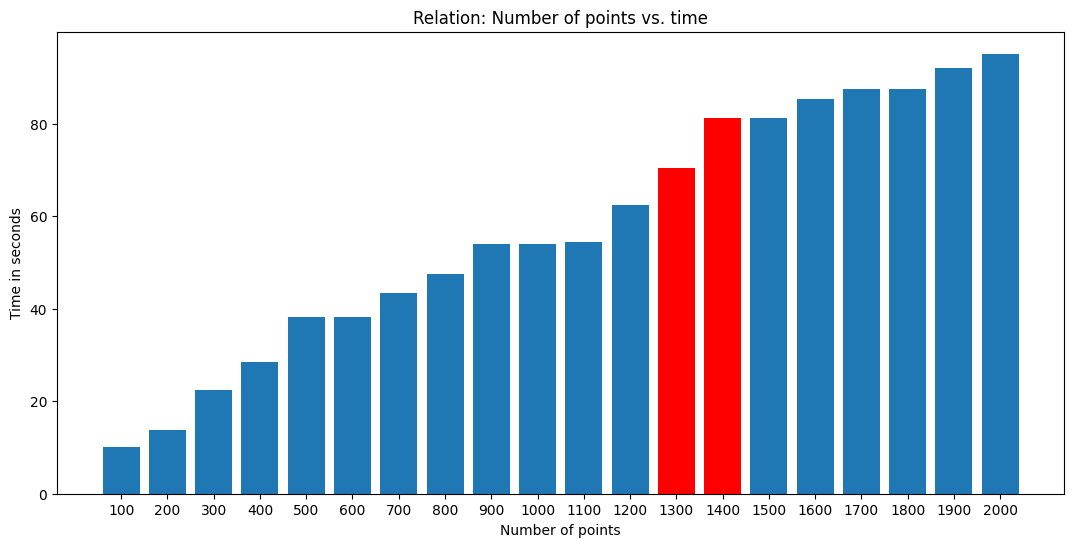

In [34]:
with open("time_water_stats.json", "r") as file:
    time_list = json.load(file)

x = list(time_list.keys())
y = list(time_list.values())

filter_times = pd.Series(y).rolling(window=3, center=True, min_periods=1).median().tolist()
y_new = filter_times
diff = np.diff(filter_times)
jump_idx = np.argmax(diff)+1
print(f"The highest jump is at {x[jump_idx]} points: {y[jump_idx]} s to {x[jump_idx-1]} points: {y[jump_idx-1]} s ({y[jump_idx]-y[jump_idx-1]}s)")
plt.figure(figsize=(13, 6))
plt.bar(x, y_new)
plt.bar(x[jump_idx-1], y[jump_idx-1], color="red")
plt.bar(x[jump_idx], y[jump_idx], color="red")

plt.xlabel("Number of points")
plt.ylabel("Time in seconds")
plt.title("Relation: Number of points vs. time")
plt.show()

The subIDs of the points with a water content of at least 95% are: [385, 455, 476, 573, 892, 905, 945]


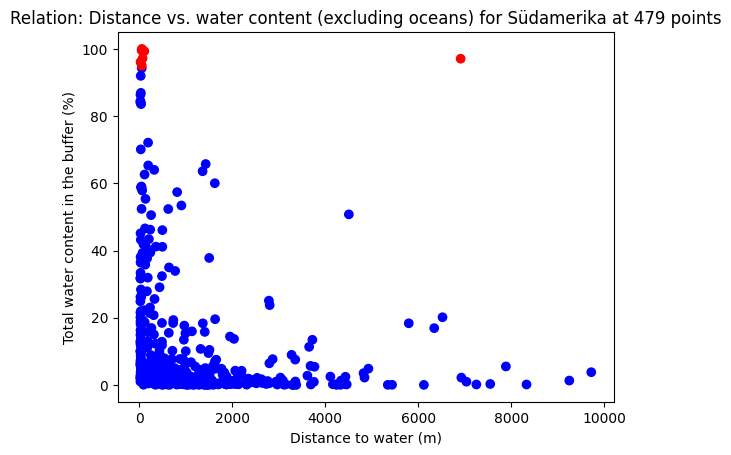

In [35]:
incsv = pd.read_csv(CSV_DIR / "input_water_stats.csv")
csv = pd.read_csv(CSV_DIR / "output_water_stats.csv")
chosen_contient = incsv["contient"][0]

clean_csv = csv[csv["is_ocean_or_dry"] == False]
sample_size = len(clean_csv)

x_distance = clean_csv["distance_to_water_meter"]
y_percentage = clean_csv["percentage_total_water_in_buffer"]

huge_subIDs = csv.loc[
    (csv["is_ocean_or_dry"] == False) & (csv["percentage_total_water_in_buffer"] >= 95.0), 
    "subID"
]
print(f"The subIDs of the points with a water content of at least 95% are: {huge_subIDs.tolist()}")
huge_subIDs_colors = ['red' if subID in huge_subIDs.tolist() else 'blue' for subID in clean_csv['subID']]

plt.scatter(x_distance, y_percentage, c=huge_subIDs_colors)
plt.xlabel("Distance to water (m)")
plt.ylabel("Total water content in the buffer (%)")
plt.title(f"Relation: Distance vs. water content (excluding oceans) for {chosen_contient} at {sample_size} points")
plt.show()